In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize

In [4]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)

In [5]:
train_data, train_labels = data_loader.load_all_train_data()

Loading calibrated train data...


In [6]:
train_data.shape, train_labels.shape

((1100, 1406, 283), (1100, 283))

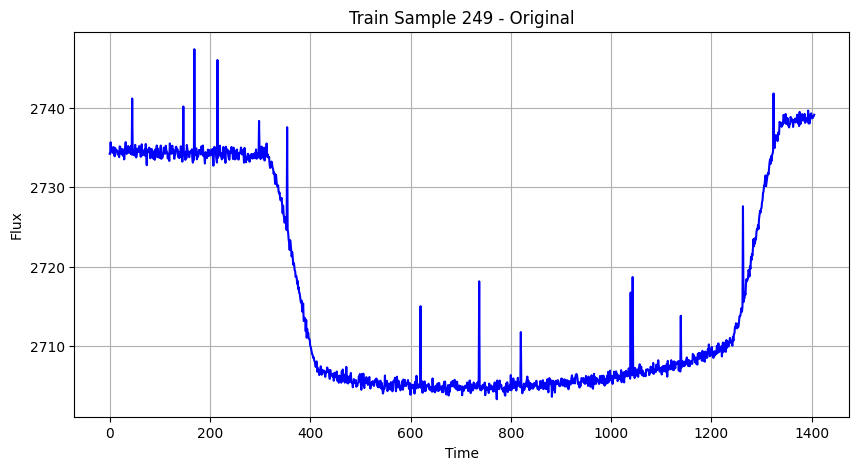

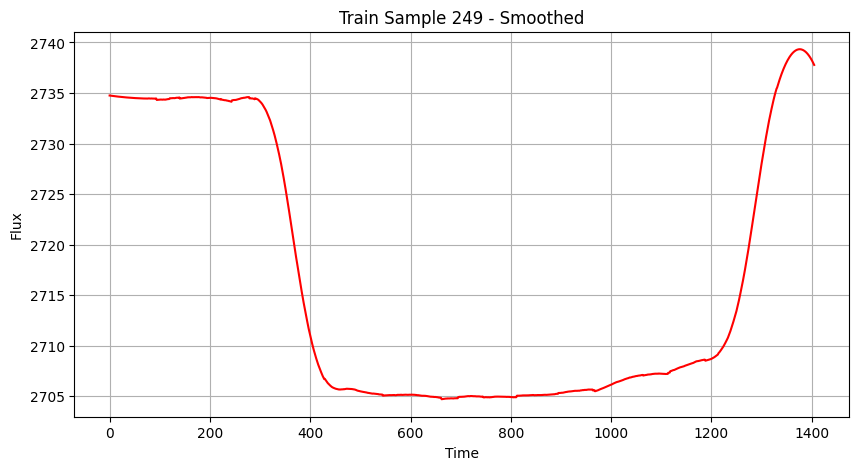

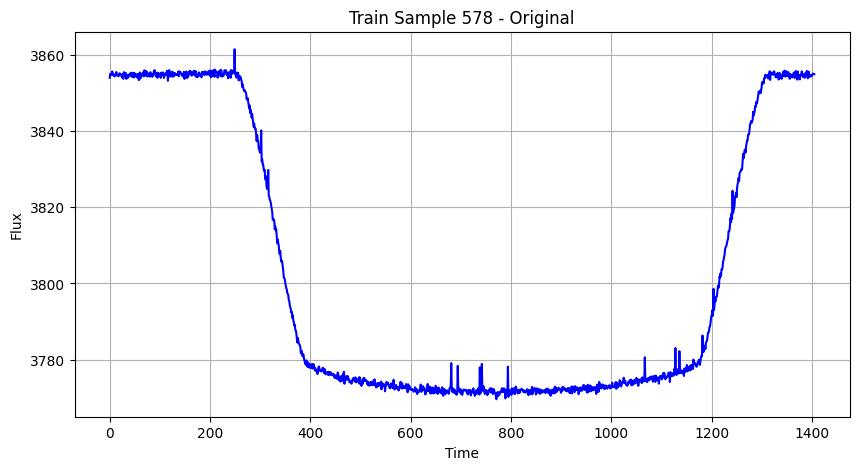

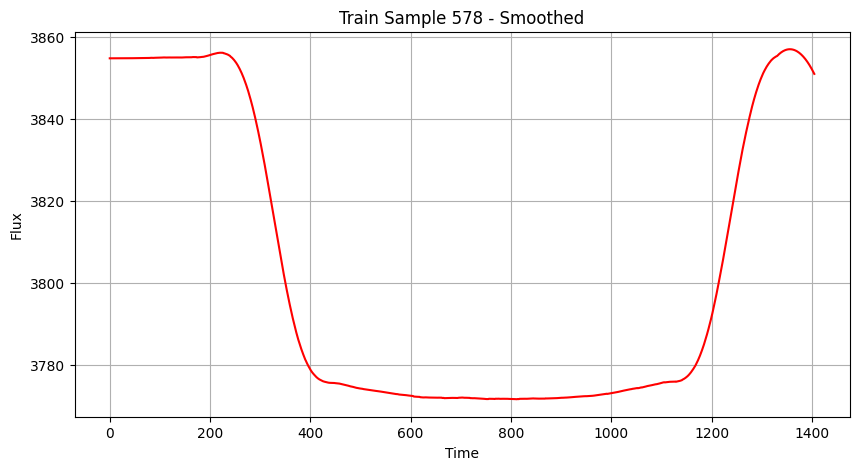

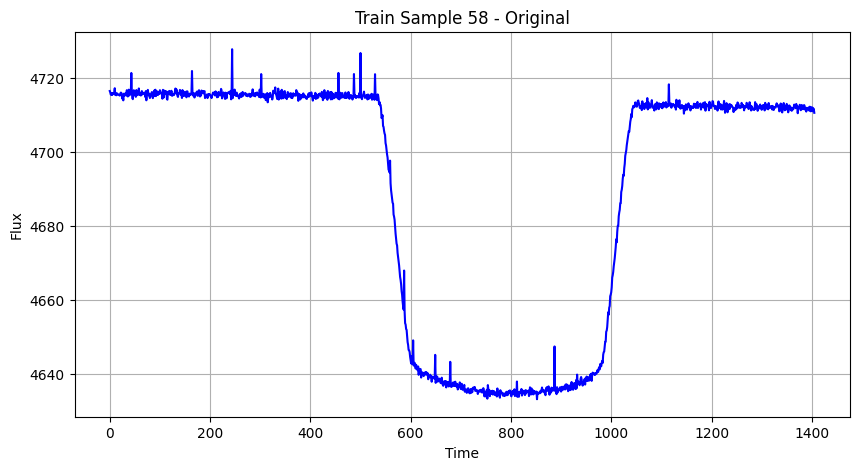

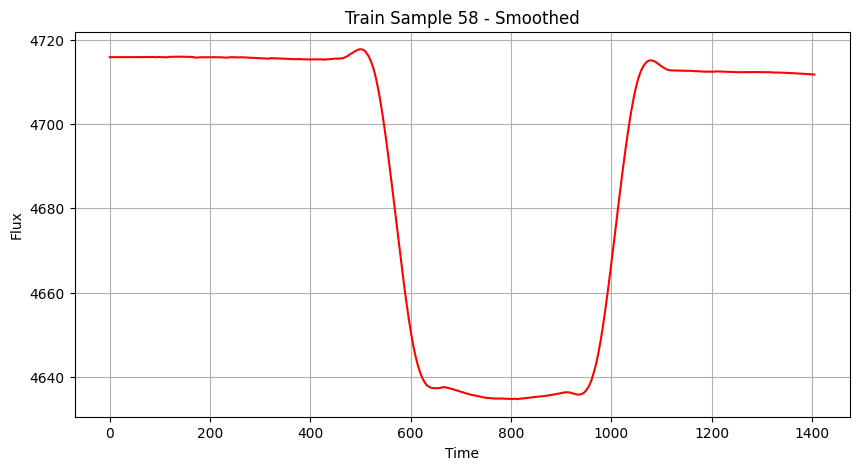

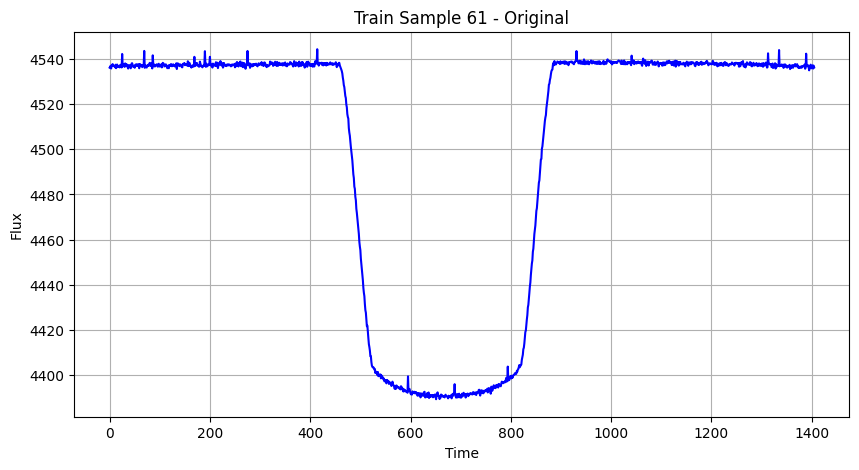

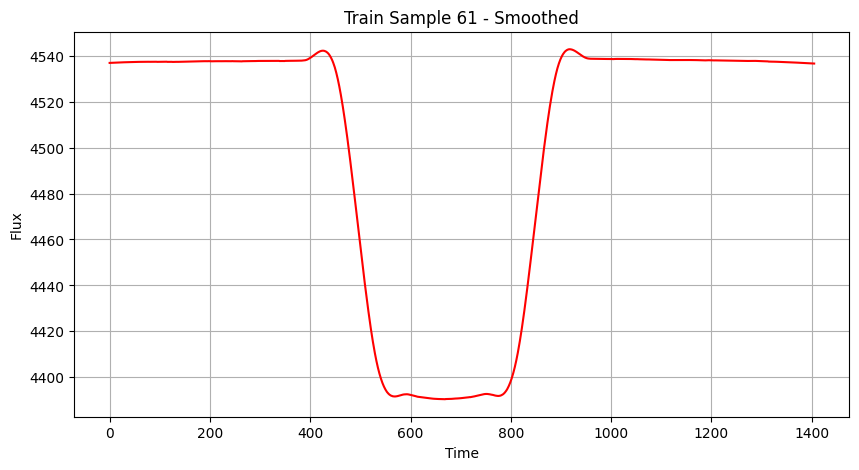

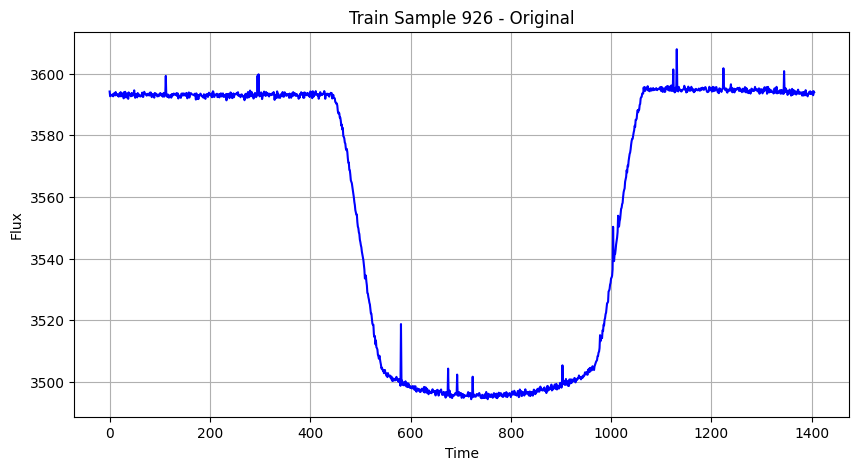

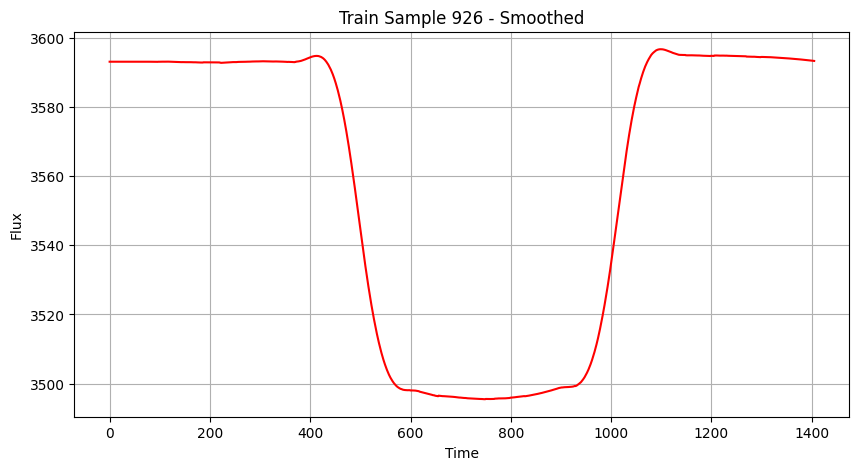

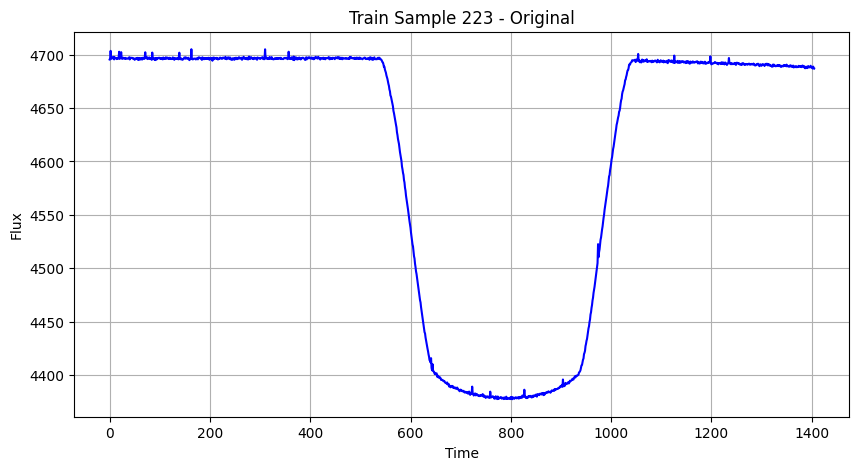

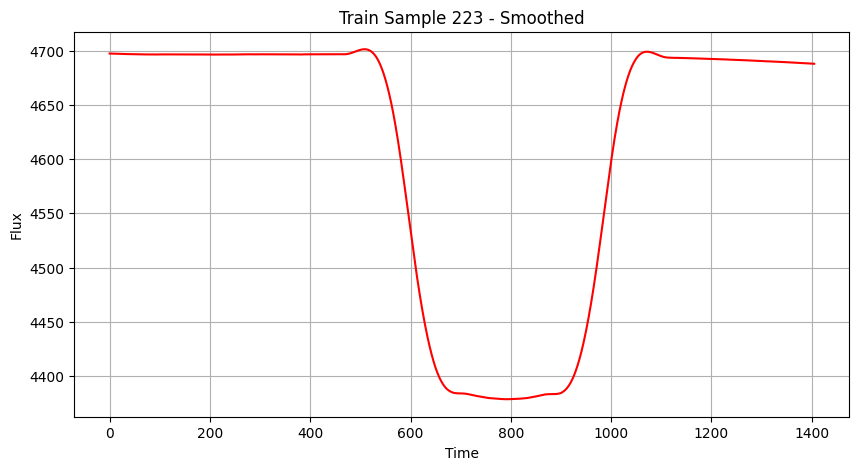

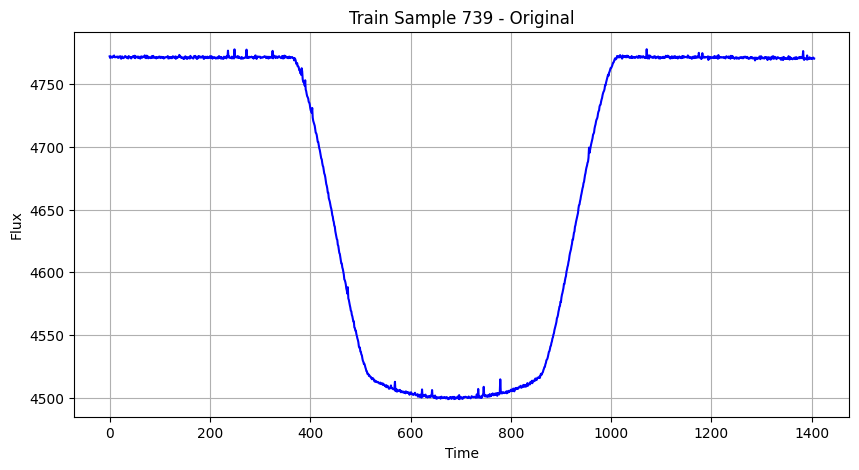

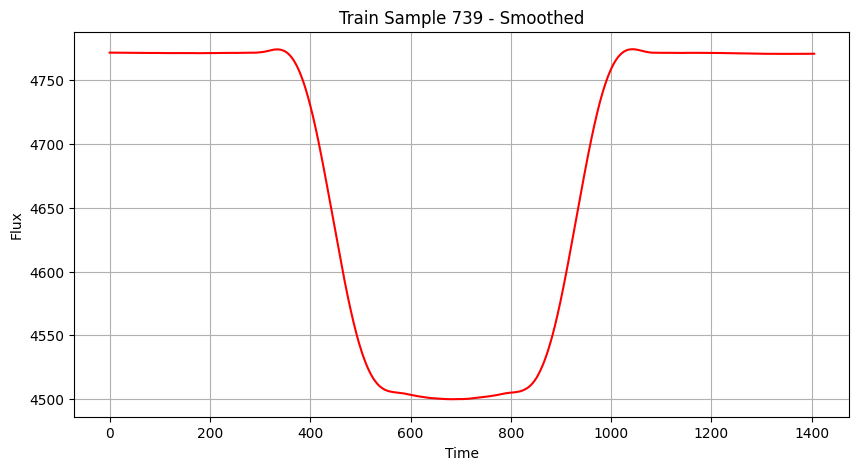

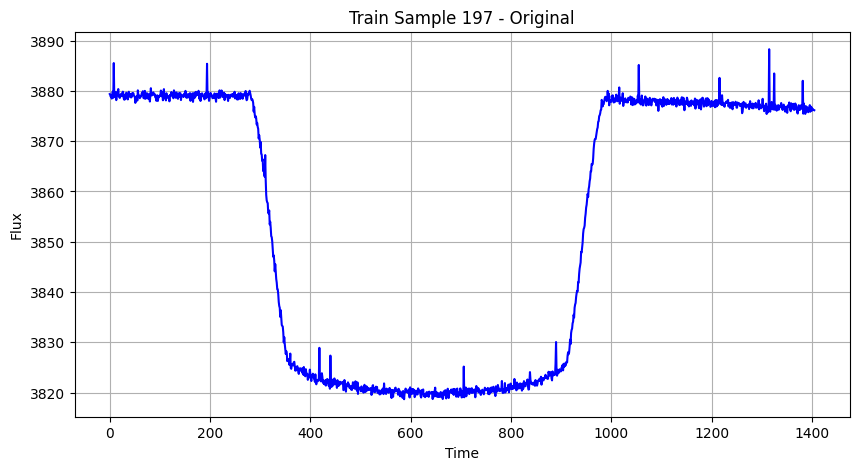

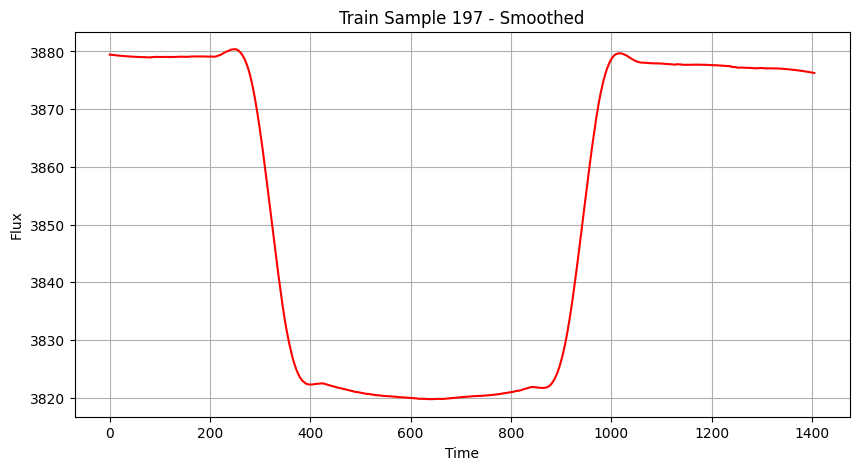

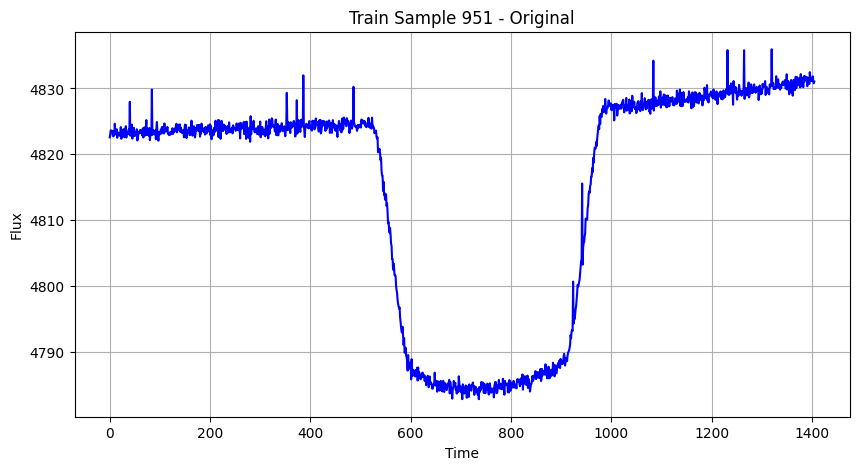

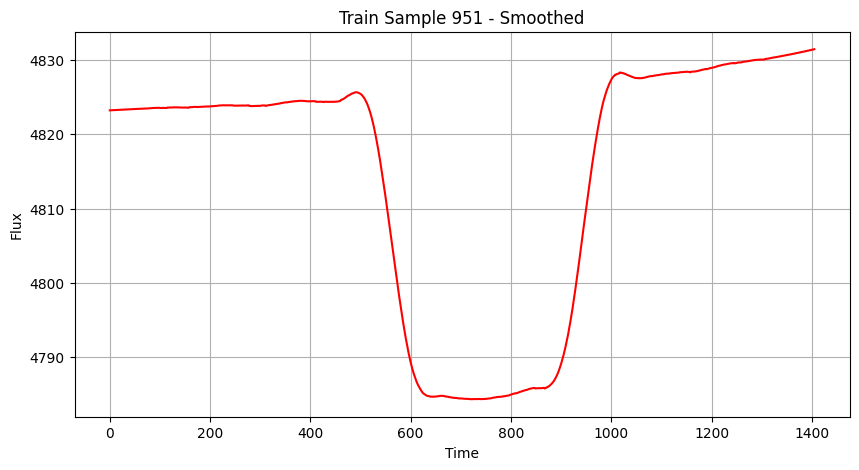

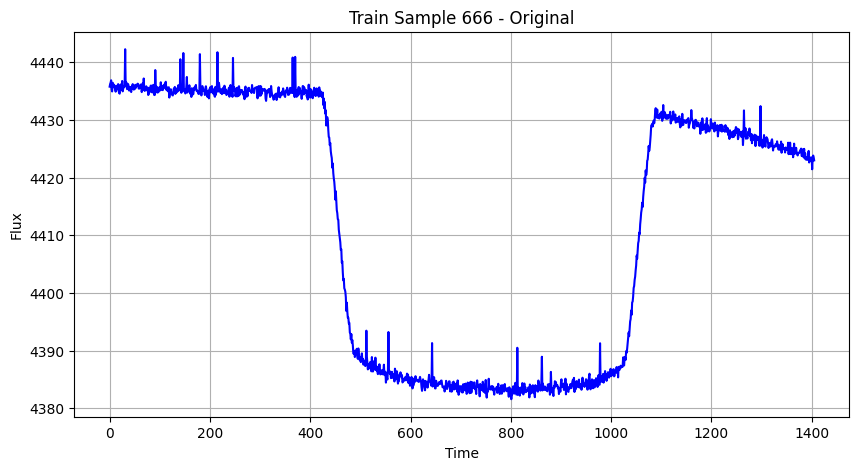

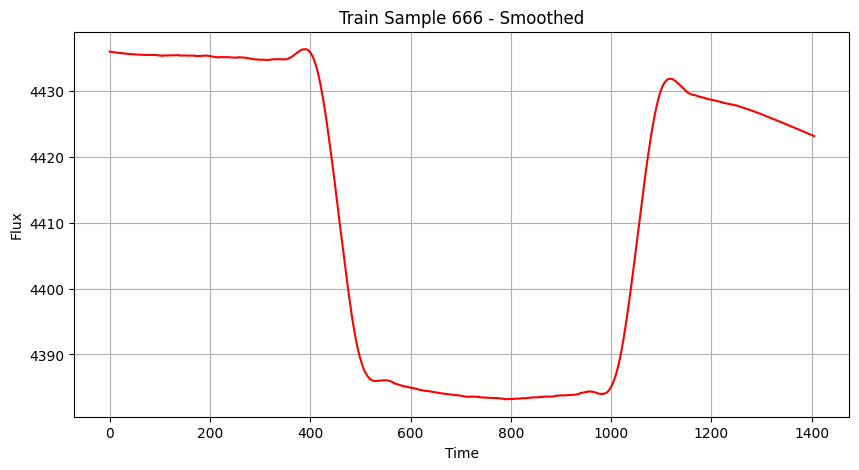

In [7]:
smoother = SGSmoothing(window_size=150, poly_order=2)
ten_random_indices = random.sample(range(train_data.shape[0]), 10)
for i in ten_random_indices:
    # Plot original and smoothed white curve for first 10 samples
    plot_white_curve(train_data[i], title=f"Train Sample {i+1} - Original", color="blue")
    plot_white_curve(smoother.smooth(train_data[i].mean(axis=1)), title=f"Train Sample {i+1} - Smoothed", color="red")
    plt.show()

In [8]:
def cost_function(params, data):
    t1, t2, a, b = params
    t1 = int(t1)
    t2 = int(t2)
    
    # Constrain Violation
    if t1 > t2:
        return(t1 - t2) * 1e9
    
    y = np.full((data.shape[0], ), a)
    y[t1:t2] = np.linspace(a, b, t2-t1)
    y[t2:] = b
    
    cost = np.sum((data - y) ** 2)
    
    return cost

Randomly selected index: 242
Min idx on data: 100, Max idx on data: 1282


/Users/ibrahimhabib/Desktop/development/ariel-2025/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ibrahimhabib/Desktop/development/ariel-2025/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/gr/hcjptshj2_l1mqdwnfv3krh40000gn/T/ipykernel_28778/3357884945.py:30: OptimizeWarning: Initial guess is not within the specified bounds
  result = minimize(cost_function, initial_params, args=(data,), bounds=bounds, method='Nelder-Mead')


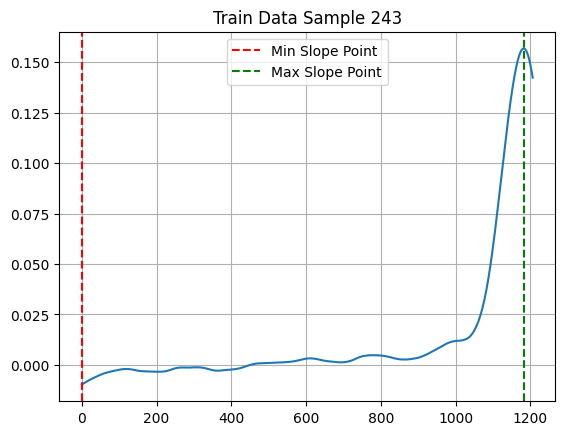

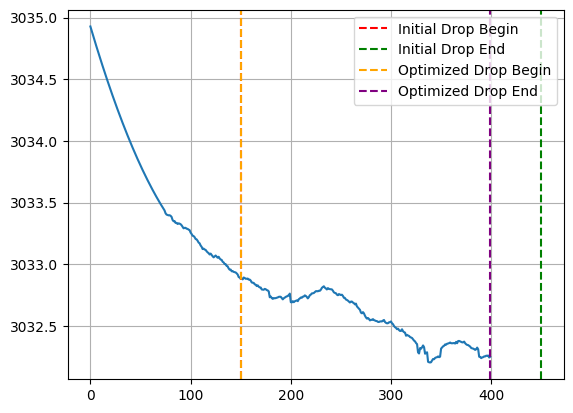

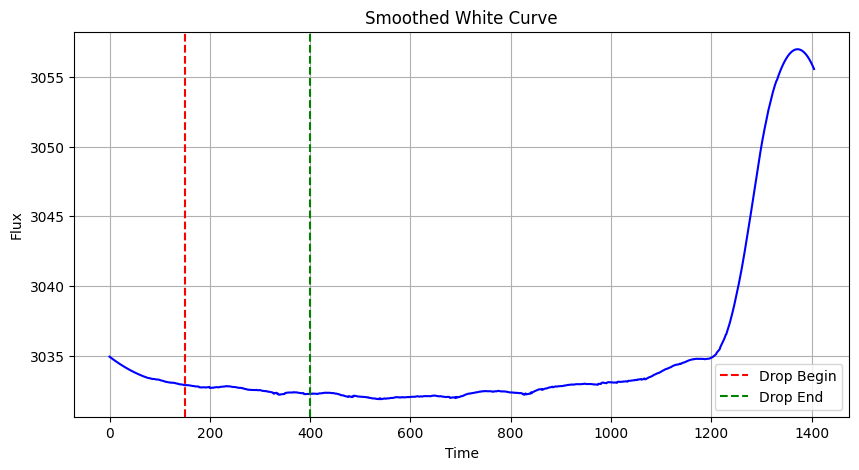

([150, 450, np.float64(3033.624295624186), np.float64(nan)],
 [(1, 398),
  (2, 399),
  (np.float64(3032.2034193186155), np.float64(3034.9285318488282)),
  (np.float64(3032.2034193186155), np.float64(3034.9285318488282))])

In [9]:
# random_index = random.randint(0, train_data.shape[0] - 1)
random_index = 242
print(f"Randomly selected index: {random_index}")
data = train_data[random_index].copy()
data = data.mean(axis=1)
data = smoother.smooth(data)

window_size = 100
kernel = np.ones(window_size) / window_size
moving_average = np.convolve(data, kernel, mode='valid')
diff = np.diff(moving_average)
moving_average_diff = np.convolve(diff, kernel, mode='valid')
min_idx = np.argmin(moving_average_diff)
max_idx = np.argmax(moving_average_diff)
min_idx_on_data = min_idx + window_size
max_idx_on_data = max_idx + window_size
print(f"Min idx on data: {min_idx_on_data}, Max idx on data: {max_idx_on_data}")
signal = data.copy()

# Get Transit Drop Region
width = 300
data = signal[max(0, min_idx_on_data-width): min(len(signal), min_idx_on_data+width)] # type: ignore
    
initial_params = [width//2, width*3//2, np.mean(data[:width//2]), np.mean(data[width*3//2:])]
bounds = [(1, len(data) - 2),
              (2, len(data) - 1),
              (min(data), max(data)),
              (min(data), max(data))]

result = minimize(cost_function, initial_params, args=(data,), bounds=bounds, method='Nelder-Mead')
t1_opt, t2_opt, a_opt, b_opt = result.x
t1_opt = int(t1_opt)
t2_opt = int(t2_opt)
t1_opt_on_data =t1_opt + max(0, min_idx_on_data-width) # type: ignore
t2_opt_on_data = t2_opt + max(0, min_idx_on_data-width) # type: ignore

plt.title(f"Train Data Sample {random_index+1}")
plt.plot(moving_average_diff)
plt.axvline(float(min_idx), color='red', linestyle='--', label='Min Slope Point')
plt.axvline(float(max_idx), color='green', linestyle='--', label='Max Slope Point')
plt.legend()
plt.grid()
plt.show()

plt.plot(data)
plt.axvline(float(initial_params[0]), color='red', linestyle='--', label='Initial Drop Begin')
plt.axvline(float(initial_params[1]), color='green', linestyle='--', label='Initial Drop End')
plt.axvline(float(t1_opt), color='orange', linestyle='--', label='Optimized Drop Begin')
plt.axvline(float(t2_opt), color='purple', linestyle='--', label='Optimized Drop End')
plt.legend()
plt.grid()
plt.show()

plot_white_curve(smoother.smooth(train_data[random_index].mean(axis=1)), title="Smoothed White Curve", color="blue")
plt.axvline(float(t1_opt_on_data), color='red', linestyle='--', label='Drop Begin')
plt.axvline(float(t2_opt_on_data), color='green', linestyle='--', label='Drop End')
plt.legend()
plt.show()

# data.shape, moving_average.shape, diff.shape, moving_average_diff.shape, initial_params, bounds
initial_params, bounds

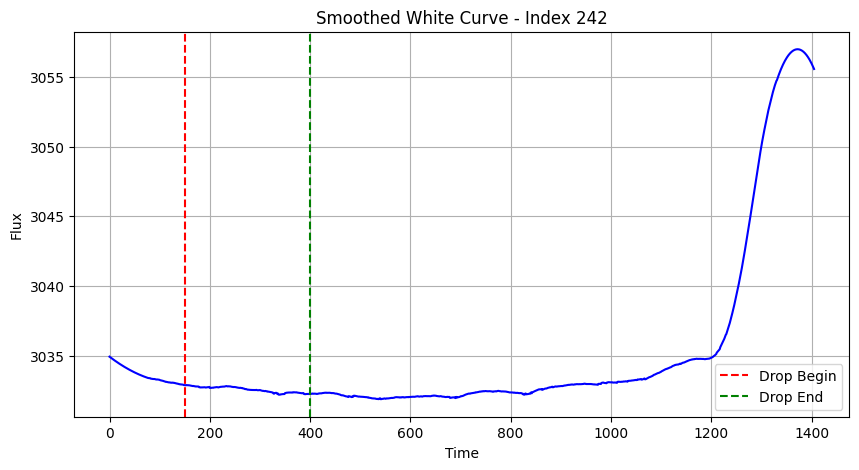

In [10]:
plot_white_curve(smoother.smooth(train_data[random_index].mean(axis=1)), title=f"Smoothed White Curve - Index {random_index}", color="blue")
plt.axvline(float(t1_opt_on_data), color='red', linestyle='--', label='Drop Begin')
plt.axvline(float(t2_opt_on_data), color='green', linestyle='--', label='Drop End')
plt.legend()
plt.show()

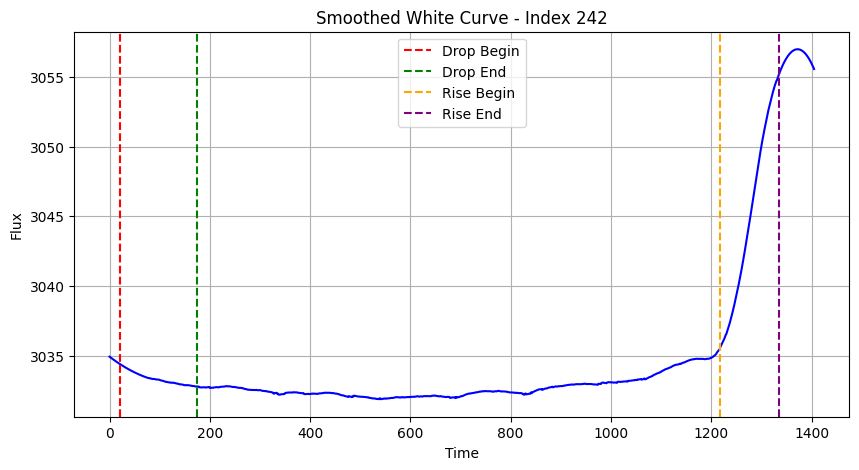

In [12]:
# random_index = random.randint(0, train_data.shape[0] - 1)
random_index = 242
signal = train_data[random_index].copy().mean(axis=1)
smoother = SGSmoothing(window_size=150, poly_order=2)
signal = smoother.smooth(signal)
transit_detector = FunctionFittingBasedPhaseDetector()
drop_begin, drop_end, rise_begin, rise_end = transit_detector.phase_detect(signal)
plot_white_curve(signal, title=f"Smoothed White Curve - Index {random_index}", color="blue")
plt.axvline(float(drop_begin), color='red', linestyle='--', label='Drop Begin')
plt.axvline(float(drop_end), color='green', linestyle='--', label='Drop End')
plt.axvline(float(rise_begin), color='orange', linestyle='--', label='Rise Begin')
plt.axvline(float(rise_end), color='purple', linestyle='--', label='Rise End')
plt.legend()
plt.show()